<a href="https://colab.research.google.com/github/Hakan-AKILLI/Anomaly-Detection-with-SMOTE/blob/main/SMOTE_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly-Detection-with-SMOTE

Ağ trafik logları yükleniyor...
Veri seti başarıyla yüklendi!

Ağ Trafiği Sınıf Dağılımı:
Attack_Category
Normal                67343
DoS                   45927
Probe (Tarama)        11656
R2L (Sızma)             995
U2R (Root Yetkisi)       52
Name: count, dtype: int64

En tehlikeli sızma saldırılarının (U2R ve R2L) tüm trafiğe oranı: Sadece % 0.831!


/tmp/ipykernel_4972/1240724888.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attack_Category', data=df, order=kategori_sayilari.index, palette='magma')


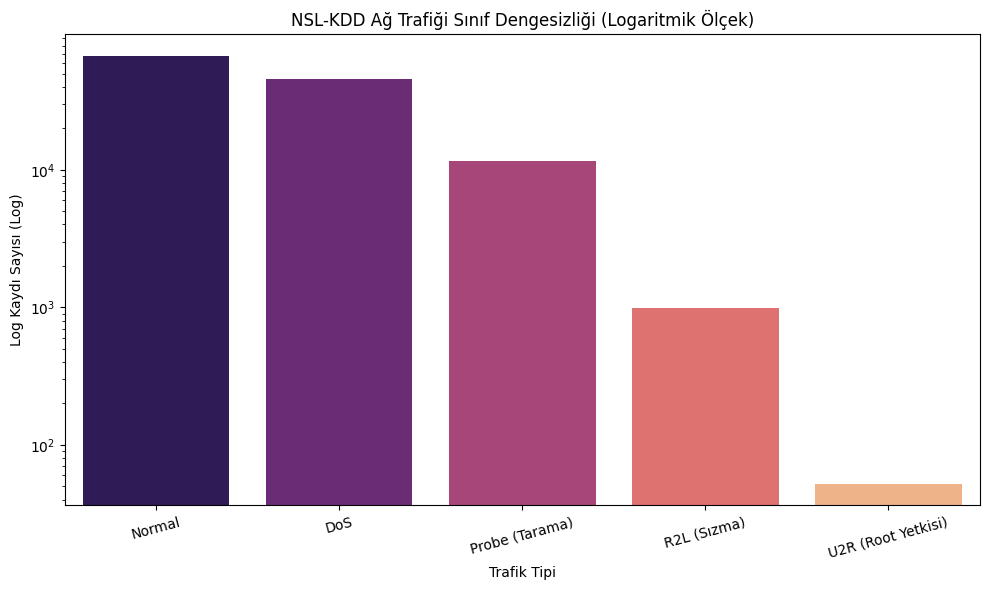

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NSL-KDD veri setinin standart ağ paketi özellikleri (41 özellik + 1 etiket)
kolonlar = ["duration", "protocol_type", "service", "flag", "src_bytes",
            "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
            "num_failed_logins", "logged_in", "num_compromised", "root_shell",
            "su_attempted", "num_root", "num_file_creations", "num_shells",
            "num_access_files", "num_outbound_cmds", "is_host_login",
            "is_guest_login", "count", "srv_count", "serror_rate",
            "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
            "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
            "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
            "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
            "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
            "dst_host_srv_rerror_rate", "label"]

# Veriyi yüklüyoruz
print("Ağ trafik logları yükleniyor...")
df = pd.read_csv('KDDTrain+.txt', names=kolonlar, usecols=range(42))
print("Veri seti başarıyla yüklendi!\n")

# Alt saldırı türlerini 4 ana siber tehdit kategorisine ayırıyoruz
saldiri_kategorileri = {
    'normal': 'Normal',
    'neptune': 'DoS', 'smurf': 'DoS', 'pod': 'DoS', 'teardrop': 'DoS', 'land': 'DoS', 'back': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS', 'mailbomb': 'DoS',
    'satan': 'Probe (Tarama)', 'ipsweep': 'Probe (Tarama)', 'nmap': 'Probe (Tarama)', 'portsweep': 'Probe (Tarama)', 'mscan': 'Probe (Tarama)', 'saint': 'Probe (Tarama)',
    'guess_passwd': 'R2L (Sızma)', 'ftp_write': 'R2L (Sızma)', 'imap': 'R2L (Sızma)', 'phf': 'R2L (Sızma)', 'multihop': 'R2L (Sızma)', 'warezmaster': 'R2L (Sızma)', 'warezclient': 'R2L (Sızma)', 'spy': 'R2L (Sızma)', 'xlock': 'R2L (Sızma)', 'xsnoop': 'R2L (Sızma)', 'snmpguess': 'R2L (Sızma)', 'snmpgetattack': 'R2L (Sızma)', 'httptunnel': 'R2L (Sızma)', 'sendmail': 'R2L (Sızma)', 'named': 'R2L (Sızma)',
    'buffer_overflow': 'U2R (Root Yetkisi)', 'loadmodule': 'U2R (Root Yetkisi)', 'rootkit': 'U2R (Root Yetkisi)', 'perl': 'U2R (Root Yetkisi)', 'sqlattack': 'U2R (Root Yetkisi)', 'xterm': 'U2R (Root Yetkisi)', 'ps': 'U2R (Root Yetkisi)'
}

# Etiketleri ana kategorilere eşleyelim
df['Attack_Category'] = df['label'].map(lambda x: saldiri_kategorileri.get(x, 'Bilinmeyen (0-Day)'))

# Dağılımı hesaplayıp ekrana yazdıralım
kategori_sayilari = df['Attack_Category'].value_counts()
print("Ağ Trafiği Sınıf Dağılımı:")
print(kategori_sayilari)

# U2R ve R2L gibi nadir ama kritik saldırıların oranını hesaplayalım
toplam_kayit = len(df)
nadir_saldirilar = kategori_sayilari.get('U2R (Root Yetkisi)', 0) + kategori_sayilari.get('R2L (Sızma)', 0)
print(f"\nEn tehlikeli sızma saldırılarının (U2R ve R2L) tüm trafiğe oranı: Sadece % {(nadir_saldirilar / toplam_kayit) * 100:.3f}!")

# Sınıf Dengesizliği Grafiği
plt.figure(figsize=(10, 6))
#Y eksenini saldırıların görünebilmesi için Logaritmik yapıyoruz
sns.countplot(x='Attack_Category', data=df, order=kategori_sayilari.index, palette='magma')
plt.title('NSL-KDD Ağ Trafiği Sınıf Dengesizliği (Logaritmik Ölçek)')
plt.xlabel('Trafik Tipi')
plt.ylabel('Log Kaydı Sayısı (Log)')
plt.yscale('log')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

print("1. Veriler yapay zekanın anlayacağı sayılara dönüştürülüyor (Encoding)...")
# Verimizdeki metin içeren sütunları buluyoruz
kategorik_sutunlar = ['protocol_type', 'service', 'flag', 'Attack_Category']
le = LabelEncoder()

# Her bir metin sütununu sayılara çeviriyoruz (Örn: tcp=1, udp=2 gibi)
for sutun in kategorik_sutunlar:
    df[sutun] = le.fit_transform(df[sutun])

# Orijinal verideki 'label' sütununu atıyoruz
df = df.drop('label', axis=1)

print("2. Veri 'Eğitim' ve 'Test' olarak ikiye ayrılıyor...")
# X:  özellikler (Attack_Category hariç her şey)
# y:  hedef (Sadece Attack_Category)
X = df.drop('Attack_Category', axis=1)
y = df['Attack_Category']

# Verinin %80'iyle modeli eğiteceğiz, %20'sini ise saklayıp test için kullanacağız
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("3. Tembel Baseline Model (Karar Ağacı) eğitiliyor...\n")
# Karar Ağacı modelini çağırıp, eğitim verilerimizle öğretiyoruz
tembel_model = DecisionTreeClassifier(random_state=42)
tembel_model.fit(X_train, y_train)

# Sakladığımız %20'lik test verisini sorup tahmin etmesini istiyoruz
y_tahmin = tembel_model.predict(X_test)

print("-" * 50)
print("KARAR AĞACI MODELİ SONUÇLARI (BASELINE)")
print("-" * 50)
# Genel doğruluğu yazdırıyoruz
genel_basari = accuracy_score(y_test, y_tahmin)
print(f"Genel Doğruluk (Accuracy): % {genel_basari * 100:.2f}\n")

# Detaylı karneyi (Hangi saldırıyı ne kadar iyi buldu?) yazdırıyoruz
print("Detaylı Başarı Karnesi (Classification Report):")
# Hedef sınıf isimlerini orijinal halleriyle görmek için elle yazıyoruz
sinif_isimleri = ['DoS', 'Normal', 'Probe (Tarama)', 'R2L (Sızma)', 'U2R (Root Yetkisi)']
print(classification_report(y_test, y_tahmin, target_names=sinif_isimleri, zero_division=0))

1. Veriler yapay zekanın anlayacağı sayılara dönüştürülüyor (Encoding)...
2. Veri 'Eğitim' ve 'Test' olarak ikiye ayrılıyor...
3. Tembel Baseline Model (Karar Ağacı) eğitiliyor...

--------------------------------------------------
KARAR AĞACI MODELİ SONUÇLARI (BASELINE)
--------------------------------------------------
Genel Doğruluk (Accuracy): % 99.71

Detaylı Başarı Karnesi (Classification Report):
                    precision    recall  f1-score   support

               DoS       1.00      1.00      1.00      9181
            Normal       1.00      1.00      1.00     13422
    Probe (Tarama)       1.00      0.99      0.99      2357
       R2L (Sızma)       0.95      0.95      0.95       224
U2R (Root Yetkisi)       0.58      0.64      0.61        11

          accuracy                           1.00     25195
         macro avg       0.91      0.91      0.91     25195
      weighted avg       1.00      1.00      1.00     25195



In [11]:
from imblearn.over_sampling import SMOTE

print("1. SMOTE Başlıyor: Azınlık sınıflar çoğaltılıyor...")
smote = SMOTE(random_state=42)

# SMOTE'u SADECE eğitim verisine uyguluyoruz! (Test verilerine dokunmuyoruz)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- EĞİTİM MASASINDAKİ SORU DAĞILIMI ---")
print("Eski (Adaletsiz) Durum:")
print(y_train.value_counts().to_string())
print("\nSMOTE Sonrası (Adaletli) YENİ Durum:")
print(y_train_smote.value_counts().to_string())
print("-" * 40)

print("\n2. Yeni ve Güçlü Model Eğitiliyor...")
# Aynı tembel modeli bu sefer "dengeli ve bol sorulu" veriyle çalıştırıyoruz
guclu_model = DecisionTreeClassifier(random_state=42)
guclu_model.fit(X_train_smote, y_train_smote)

print("3. Yeni Model Gerçek Sınava (X_test) Sokuluyor...")
y_tahmin_smote = guclu_model.predict(X_test)

print("\n" + "=" * 55)
print("  SMOTE SONRASI KARAR AĞACI SONUÇLARI  ")
print("=" * 55)
print(classification_report(y_test, y_tahmin_smote, target_names=sinif_isimleri, zero_division=0))

1. SMOTE Başlıyor: Azınlık sınıflar çoğaltılıyor...

--- EĞİTİM MASASINDAKİ SORU DAĞILIMI ---
Eski (Adaletsiz) Durum:
Attack_Category
1    53921
0    36746
2     9299
3      771
4       41

SMOTE Sonrası (Adaletli) YENİ Durum:
Attack_Category
1    53921
0    53921
2    53921
3    53921
4    53921
----------------------------------------

2. Yeni ve Güçlü Model Eğitiliyor...
3. Yeni Model Gerçek Sınava (X_test) Sokuluyor...

  SMOTE SONRASI KARAR AĞACI SONUÇLARI  
                    precision    recall  f1-score   support

               DoS       1.00      1.00      1.00      9181
            Normal       1.00      1.00      1.00     13422
    Probe (Tarama)       0.99      0.99      0.99      2357
       R2L (Sızma)       0.90      0.96      0.93       224
U2R (Root Yetkisi)       0.36      0.36      0.36        11

          accuracy                           1.00     25195
         macro avg       0.85      0.86      0.86     25195
      weighted avg       1.00      1.00      1.00 

In [12]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report

print("1. Modeller ve Hiperparametre Taraması Başlatılıyor...")

# Random Forest için parametre sözlüğü (Örnek değerler)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# AdaBoost için parametre sözlüğü
ada_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 1.0]
}

# Modellerin tanımlanması
rf = RandomForestClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)

# GridSearchCV Uygulaması (Random Forest için)
print("Random Forest için GridSearchCV çalışıyor...")
grid_rf = GridSearchCV(rf, rf_params, cv=3, n_jobs=-1)
grid_rf.fit(X_train_smote, y_train_smote)
best_rf = grid_rf.best_estimator_

# GridSearchCV Uygulaması (AdaBoost için)
print("AdaBoost için GridSearchCV çalışıyor...")
grid_ada = GridSearchCV(ada, ada_params, cv=3, n_jobs=-1)
grid_ada.fit(X_train_smote, y_train_smote)
best_ada = grid_ada.best_estimator_

print(f"\nEn İyi RF Parametreleri: {grid_rf.best_params_}")
print(f"En İyi AdaBoost Parametreleri: {grid_ada.best_params_}")

print("\n2. k-fold Cross-Validation Uygulanıyor (k=5)...")

# Modellerin k-fold ile tutarlılık testi
rf_cv_scores = cross_val_score(best_rf, X_train_smote, y_train_smote, cv=5)
ada_cv_scores = cross_val_score(best_ada, X_train_smote, y_train_smote, cv=5)

print(f"Random Forest CV Ortalama Başarı: % {rf_cv_scores.mean() * 100:.2f}")
print(f"AdaBoost CV Ortalama Başarı: % {ada_cv_scores.mean() * 100:.2f}")

# Test seti üzerinde son tahminlerin yapılması
y_pred_rf = best_rf.predict(X_test)
y_pred_ada = best_ada.predict(X_test)

print("\n--- Random Forest Test Sonuçları ---")
print(classification_report(y_test, y_pred_rf, target_names=sinif_isimleri))

print("\n--- AdaBoost Test Sonuçları ---")
print(classification_report(y_test, y_pred_ada, target_names=sinif_isimleri))

1. Modeller ve Hiperparametre Taraması Başlatılıyor...
Random Forest için GridSearchCV çalışıyor...
AdaBoost için GridSearchCV çalışıyor...

En İyi RF Parametreleri: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
En İyi AdaBoost Parametreleri: {'learning_rate': 1.0, 'n_estimators': 100}

2. k-fold Cross-Validation Uygulanıyor (k=5)...
Random Forest CV Ortalama Başarı: % 99.97
AdaBoost CV Ortalama Başarı: % 92.38

--- Random Forest Test Sonuçları ---
                    precision    recall  f1-score   support

               DoS       1.00      1.00      1.00      9181
            Normal       1.00      1.00      1.00     13422
    Probe (Tarama)       1.00      1.00      1.00      2357
       R2L (Sızma)       1.00      0.99      0.99       224
U2R (Root Yetkisi)       0.86      0.55      0.67        11

          accuracy                           1.00     25195
         macro avg       0.97      0.91      0.93     25195
      weighted avg       1.00      1.00      1

1. Karmaşıklık Matrisi (Confusion Matrix) Hesaplanıyor...
2. Bir Isı Haritası (Heatmap) Çizdiriliyor...



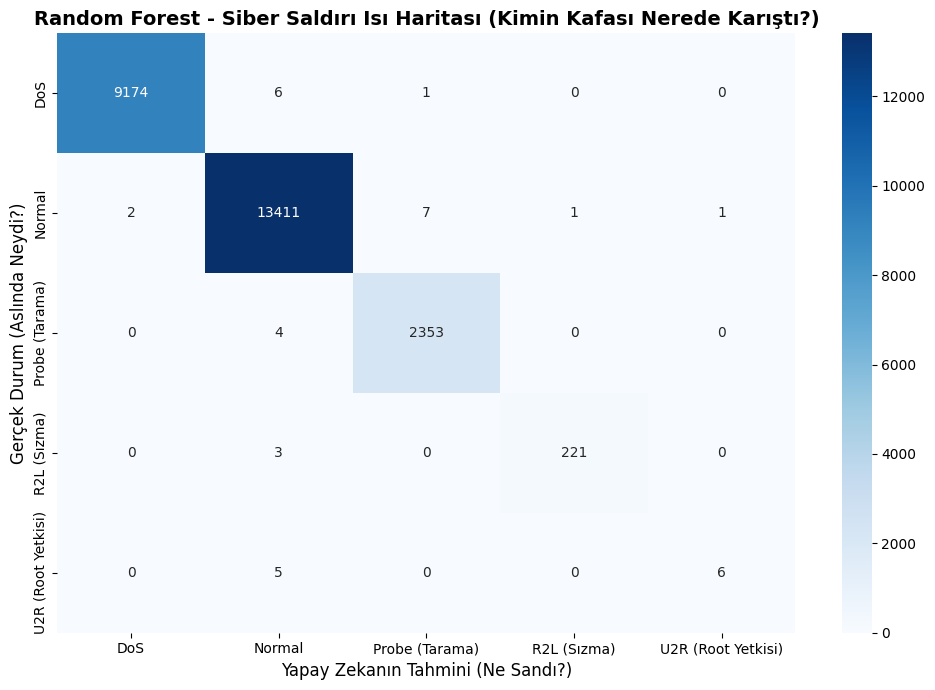

In [14]:
from sklearn.metrics import confusion_matrix

print("1. Karmaşıklık Matrisi (Confusion Matrix) Hesaplanıyor...")
# Modelimizin sınavda verdiği cevaplar ile gerçek cevap anahtarını kıyaslıyoruz
cm = confusion_matrix(y_test, y_tahmin_orman)

print("2. Bir Isı Haritası (Heatmap) Çizdiriliyor...\n")
plt.figure(figsize=(10, 7))

# Seaborn kütüphanesiyle mavi tonlarında (Blues) çok şık bir ısı haritası çizdiriyoruz
# annot=True diyerek kutuların içine tam sayıları (fmt='d') yazdırıyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sinif_isimleri, yticklabels=sinif_isimleri)

plt.title('Random Forest - Siber Saldırı Isı Haritası (Kimin Kafası Nerede Karıştı?)', fontsize=14, fontweight='bold')
plt.xlabel('Yapay Zekanın Tahmini (Ne Sandı?)', fontsize=12)
plt.ylabel('Gerçek Durum (Aslında Neydi?)', fontsize=12)

plt.tight_layout()
plt.show()

3. Performans Karşılaştırma ve Görselleştirme Başlatılıyor...


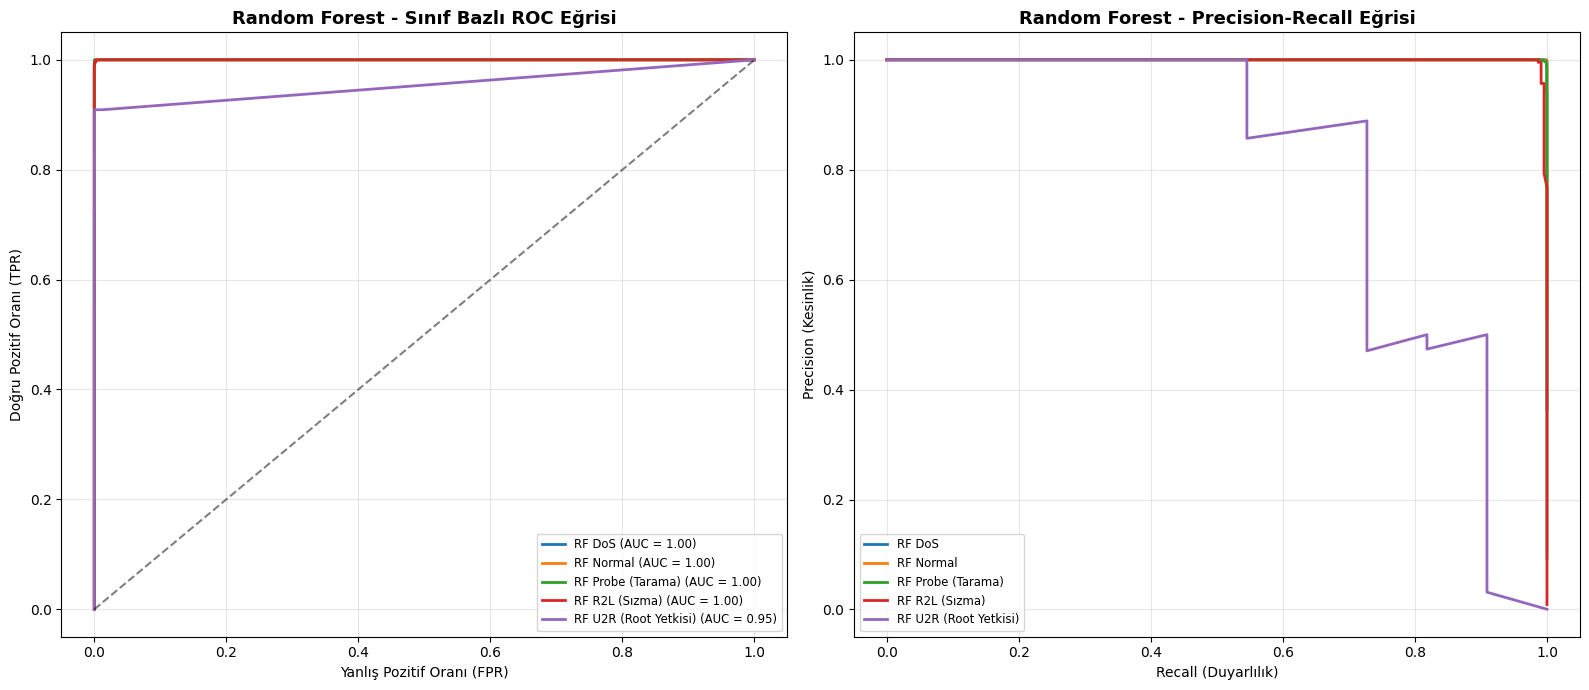

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

print("3. Performans Karşılaştırma ve Görselleştirme Başlatılıyor...")

# Sınıfları ROC eğrisi için uygun formata getiriyoruz (Binarize)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Modellerin her sınıf için olasılık skorlarını alıyoruz
y_score_rf = best_rf.predict_proba(X_test)
y_score_ada = best_ada.predict_proba(X_test)

# Grafik alanı oluşturma
plt.figure(figsize=(16, 7))

# --- 1. ROC Eğrisi Çizimi ---
plt.subplot(1, 2, 1)
# Random Forest için sınıfların ortalamasını (Macro Average) görselleştirme örneği
for i, label in enumerate(sinif_isimleri):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    plt.plot(fpr, tpr, label=f'RF {label} (AUC = {auc(fpr, tpr):.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Random Forest - Sınıf Bazlı ROC Eğrisi', fontsize=13, fontweight='bold')
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)

# --- 2. Precision-Recall Eğrisi Çizimi ---
plt.subplot(1, 2, 2)
for i, label in enumerate(sinif_isimleri):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_rf[:, i])
    plt.plot(recall, precision, label=f'RF {label}', linewidth=2)

plt.title('Random Forest - Precision-Recall Eğrisi', fontsize=13, fontweight='bold')
plt.xlabel('Recall (Duyarlılık)')
plt.ylabel('Precision (Kesinlik)')
plt.legend(loc='lower left', fontsize='small')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Modelin Beyni Açılıyor: En Önemli Özellikler Çıkarılıyor...
2. Bir Grafik Çizdiriliyor...



/tmp/ipykernel_4972/2457460932.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=df_top10, palette='magma')


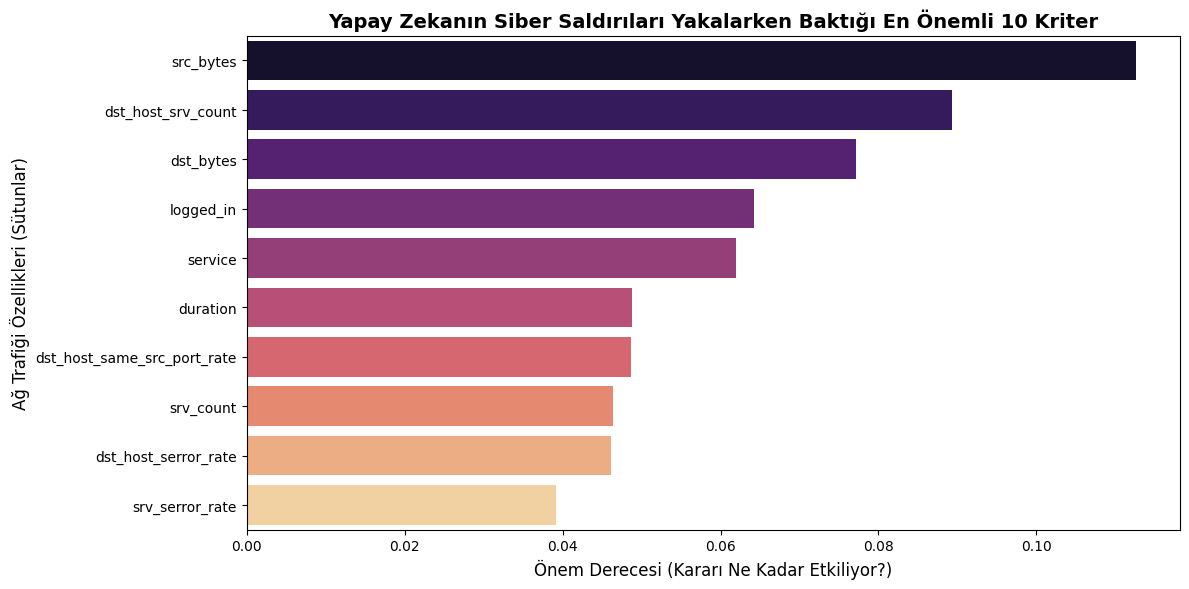

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("1. Modelin Beyni Açılıyor: En Önemli Özellikler Çıkarılıyor...")
# Orman modelimizin o 40 küsür sütuna verdiği puanları (önem derecelerini) alıyoruz
onem_dereceleri = orman_modeli.feature_importances_

# Orijinal soru kitapçığımızdaki (X) sütun isimlerini alıyoruz
ozellik_isimleri = X.columns

# Özellikleri ve modelin verdiği puanları bir tabloya (DataFrame) dönüştürüyoruz
df_onem = pd.DataFrame({'Özellik': ozellik_isimleri, 'Önem': onem_dereceleri})

# Puanlara göre büyükten küçüğe sıralayıp, sadece "En Etkili 10 Sütunu" alıyoruz
df_top10 = df_onem.sort_values(by='Önem', ascending=False).head(10)

print("2. Bir Grafik Çizdiriliyor...\n")
plt.figure(figsize=(12, 6))
sns.barplot(x='Önem', y='Özellik', data=df_top10, palette='magma')
plt.title('Yapay Zekanın Siber Saldırıları Yakalarken Baktığı En Önemli 10 Kriter', fontsize=14, fontweight='bold')
plt.xlabel('Önem Derecesi (Kararı Ne Kadar Etkiliyor?)', fontsize=12)
plt.ylabel('Ağ Trafiği Özellikleri (Sütunlar)', fontsize=12)


plt.tight_layout()
plt.show()